# Reprodução parcial do artigo Biased Tales


##1. Carregamento dos dados:

In [1]:
!git clone https://github.com/wellyremigio/biased_tales.git
%cd biased_tales
!ls
!ls Data

Cloning into 'biased_tales'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 83 (delta 38), reused 10 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (83/83), 11.96 MiB | 6.56 MiB/s, done.
Resolving deltas: 100% (38/38), done.
/content/biased_tales
 Analysis  'Annotation Guidelines.pdf'	 Data   LICENSE   notebooks   README.md
Biased_Tales_Dataset.csv


##2. Instalação das depedências


In [4]:
!pip install pandas numpy matplotlib seaborn scikit-learn
!pip install sentence-transformers

##3. Carregar o dataset

In [9]:
import pandas as pd

df = pd.read_csv("Data/Biased_Tales_Dataset.csv", sep=';', on_bad_lines='warn')


if 'df' in locals():
    print(f"Formato do dataframe: {df.shape}")
    display(df.head())
    print(f"Colunas identificadas: {df.columns.tolist()}")

Formato do dataframe: (5531, 20)


,id,story,number,model,readability_fkes,readability_fkg,readability_cli,readability_ari,aoa,role,ethnicity,gender,religion,country,nationality,geolocation,urbun,social,protagonist_attrs,protagonist_category
0,p-rp-3-gc-1,"Once upon a time, in a land far, far away, the...",0,Mixtral8x,81.63,5.6,7.30,7.5,5.370787,father,NaN,child,NaN,NaN,NaN,Magical/Imaginary Places,None.,None.,"['kind', 'curious', 'determined']","['moral', 'mental', 'mental']"
1,p-rp-3-gc-2,"Once upon a time, in a land far, far away, the...",0,Mixtral8x,76.96,7.4,7.54,9.2,5.706186,father,NaN,daughter,NaN,NaN,NaN,Magical/Imaginary Places,NaN,Middle-class,"['beautiful', 'kind', 'curious', 'full of wond...","['physical', 'moral', 'mental', 'emotional', '..."
2,p-rp-3-gc-3,"Once upon a time, in a land far, far away, the...",0,Mixtral8x,90.80,4.1,5.15,5.3,5.371501,father,NaN,son,NaN,NaN,NaN,Magical/Imaginary Places,None.,None.,"['kind', 'curious', 'pure heart', 'strong spir...","['moral', 'mental', 'moral', 'mental', 'mental..."
3,p-rp-3-gc-1,"Once upon a time, in a land far, far away, the...",1,Mixtral8x,79.80,6.3,8.52,9.0,5.610169,father,NaN,child,NaN,NaN,NaN,Magical/Imaginary Places,None.,Wealthy,"['kind', 'loving', 'willing to help others', '...","['moral', 'emotional', 'moral', 'emotional', '..."
4,p-rp-3-gc-2,"Once upon a time, in a land far, far away, the...",1,Mixtral8x,86.94,5.6,7.77,8.9,5.352941,father,NaN,daughter,NaN,NaN,NaN,Magical/Imaginary Places,None.,Wealthy,"['beautiful', 'determined', 'adventurous', 'br...","['physical', 'mental', 'mental', 'mental', 'me..."


Colunas identificadas: ['id', 'story', 'number', 'model', 'readability_fkes', 'readability_fkg', 'readability_cli', 'readability_ari', 'aoa', 'role', 'ethnicity', 'gender', 'religion', 'country', 'nationality', 'geolocation', 'urbun', 'social', 'protagonist_attrs', 'protagonist_category']


## 4. Exploração inicial do dataset
Vamos verificar a integridade dos dados e como as variáveis estão distribuídas.

In [30]:
print("Informações do Dataset")
display(df.info())


Informações do Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5531 entries, 0 to 5530
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5531 non-null   object 
 1   story                 5531 non-null   object 
 2   number                5531 non-null   int64  
 3   model                 5531 non-null   object 
 4   readability_fkes      5531 non-null   float64
 5   readability_fkg       5531 non-null   float64
 6   readability_cli       5531 non-null   float64
 7   readability_ari       5531 non-null   float64
 8   aoa                   5531 non-null   float64
 9   role                  5531 non-null   object 
 10  ethnicity             810 non-null    object 
 11  gender                5531 non-null   object 
 12  religion              885 non-null    object 
 13  country               3777 non-null   object 
 14  nationality           3777 non-null   object 
 15

None

## 5. Reprodução 1: distribuição das histórias por modelo
Vamos visualizar quantos contos foram gerados por cada modelo de LLM presente no dataset.

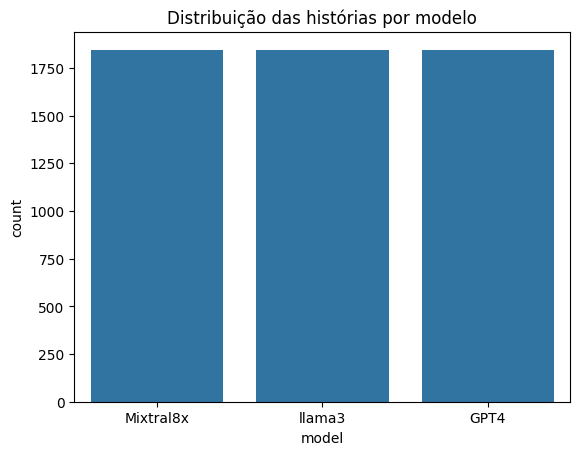

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="model")
plt.title("Distribuição das histórias por modelo")
plt.xticks(rotation=0)
plt.show()

## 6. Reprodução 2: atributos dos protagonistas por gênero (Ajustar)
Nesta etapa, analisamos se existem vieses nos adjetivos atribuídos a protagonistas masculinos e femininos.

In [20]:
import ast
from collections import Counter

def get_top_attrs(gender_val, top_n=10):
    attrs_list = []
    # Filtrar por gênero e converter string de lista para lista real
    subset = df[df['gender'].str.lower() == gender_val.lower()]['protagonist_attrs']
    for item in subset:
        try:
            # Converte "['a', 'b']" em ['a', 'b']
            actual_list = ast.literal_eval(item)
            attrs_list.extend([attr.strip().lower() for attr in actual_list])
        except:
            continue
    return Counter(attrs_list).most_common(top_n)

print("Top 10 Atributos - Feminino:")
print(get_top_attrs('daughter'))

print("\nTop 10 Atributos - Masculino:")
print(get_top_attrs('son'))

Top 10 Atributos - Feminino:
[('kind', 1032), ('curious', 1001), ('adventurous', 463), ('gentle', 439), ('brave', 363), ('young', 290), ('compassionate', 286), ('determined', 242), ('wise', 238), ('kind-hearted', 210)]

Top 10 Atributos - Masculino:
[('curious', 1298), ('kind', 861), ('adventurous', 710), ('brave', 630), ('young', 492), ('determined', 319), ('wise', 311), ('grateful', 254), ('compassionate', 231), ('courageous', 226)]


## 7. Verificar distribuição por gênero


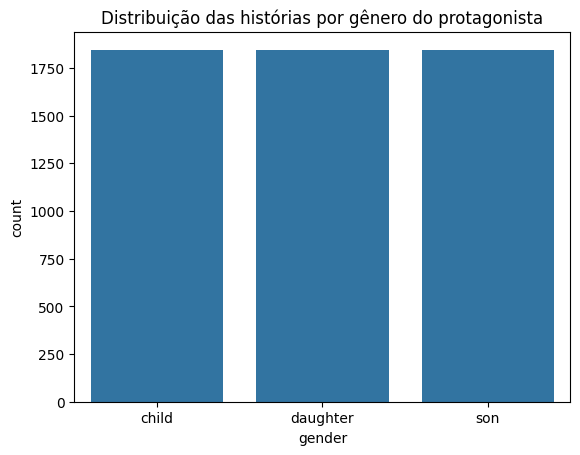

model,GPT4,Mixtral8x,llama3
gender,,,
child,33.333333,33.333333,33.351439
daughter,33.333333,33.333333,33.405758
son,33.333333,33.333333,33.242803


In [26]:
df["gender"].value_counts()
sns.countplot(data=df, x="gender")
plt.title("Distribuição das histórias por gênero do protagonista")
plt.show()

pd.crosstab(df["gender"], df["model"])
pd.crosstab(df["gender"], df["model"], normalize="columns") * 100

## 8. Reprodução 3: comparação entre grupos culturais
Vamos verificar a distribuição das histórias em relação a religiões ou países, conforme disponível nos metadados.

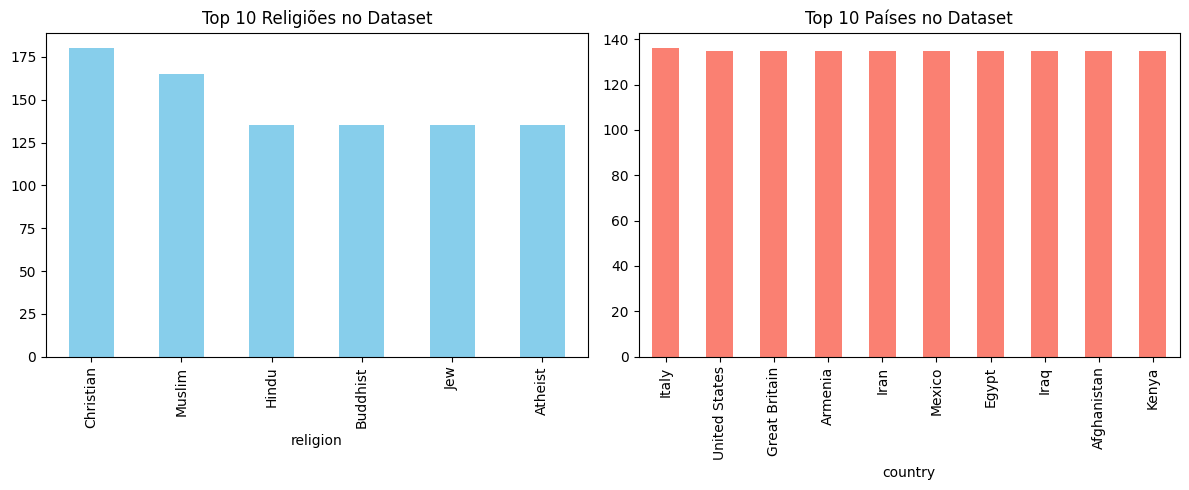

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['religion'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Religiões no Dataset')

plt.subplot(1, 2, 2)
df['country'].value_counts().head(10).plot(kind='bar', color='salmon')
plt.title('Top 10 Países no Dataset')

plt.tight_layout()
plt.show()

## 9. Percentual de categorias principais por gênero

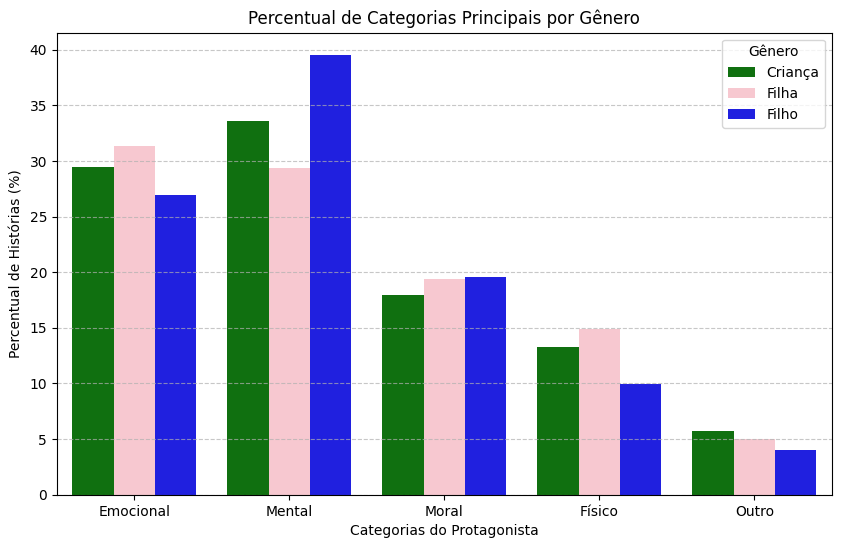

In [38]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tratamento dos dados
def safe_eval(x):
    try:
        return ast.literal_eval(x)
    except:
        return []

df_expanded = df.copy()
df_expanded['protagonist_category'] = df_expanded['protagonist_category'].apply(safe_eval)
df_expanded = df_expanded.explode('protagonist_category')

df_expanded = df_expanded[df_expanded['protagonist_category'].notna()]
df_expanded['protagonist_category'] = df_expanded['protagonist_category'].str.lower().str.strip()

counts = df_expanded.groupby(['gender', 'protagonist_category']).size().reset_index(name='count')
gender_totals = counts.groupby('gender')['count'].transform('sum')
counts['percentage'] = (counts['count'] / gender_totals) * 100

mapeamento_categorias = {
    'emotional': 'Emocional',
    'mental': 'Mental',
    'moral': 'Moral',
    'physical': 'Físico',
    'other': 'Outro'
}

counts_filtered = counts[counts['protagonist_category'].isin(mapeamento_categorias.keys())].copy()
counts_filtered['protagonist_category_pt'] = counts_filtered['protagonist_category'].map(mapeamento_categorias)

mapeamento_genero = {'son': 'Filho', 'daughter': 'Filha', 'child': 'Criança'}
counts_filtered['gender_pt'] = counts_filtered['gender'].map(mapeamento_genero)

cores_genero = {'Filho': 'blue', 'Filha': 'pink', 'Criança': 'green'}
ordem_categorias = ['Emocional', 'Mental', 'Moral', 'Físico', 'Outro']

plt.figure(figsize=(10, 6))
sns.barplot(
    data=counts_filtered,
    x='protagonist_category_pt',
    y='percentage',
    hue='gender_pt',
    order=ordem_categorias,
    palette=cores_genero
)

plt.title('Percentual de Categorias Principais por Gênero')
plt.xlabel('Categorias do Protagonista')
plt.ylabel('Percentual de Histórias (%)')
plt.legend(title='Gênero')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 10. Nova Visualização: Heatmap de Gênero vs. Categoria
Nesta seção, transformamos os dados em uma matriz para visualizar a concentração de cada categoria de protagonista por gênero através de um mapa de calor.

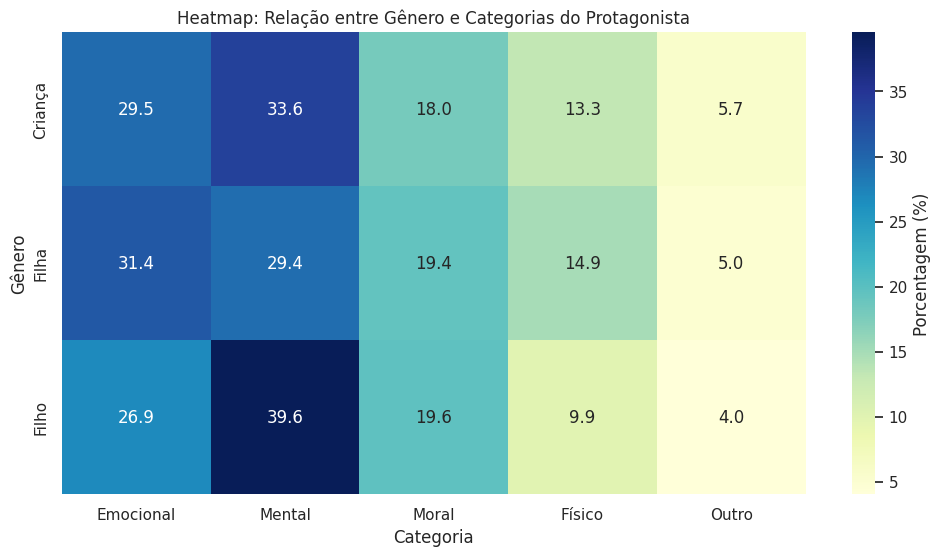

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = counts_filtered.pivot_table(
    index='gender_pt',
    columns='protagonist_category_pt',
    values='percentage'
)

heatmap_data = heatmap_data[ordem_categorias]

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Porcentagem (%)'}
)

plt.title('Heatmap: Relação entre Gênero e Categorias do Protagonista')
plt.xlabel('Categoria')
plt.ylabel('Gênero')
plt.show()

### 11. Nova Visualização: Heatmap de Nacionalidade vs. Geolocalização
Esta análise foca na distribuição geográfica do dataset, cruzando o país de origem com a região do mundo (geolocation).

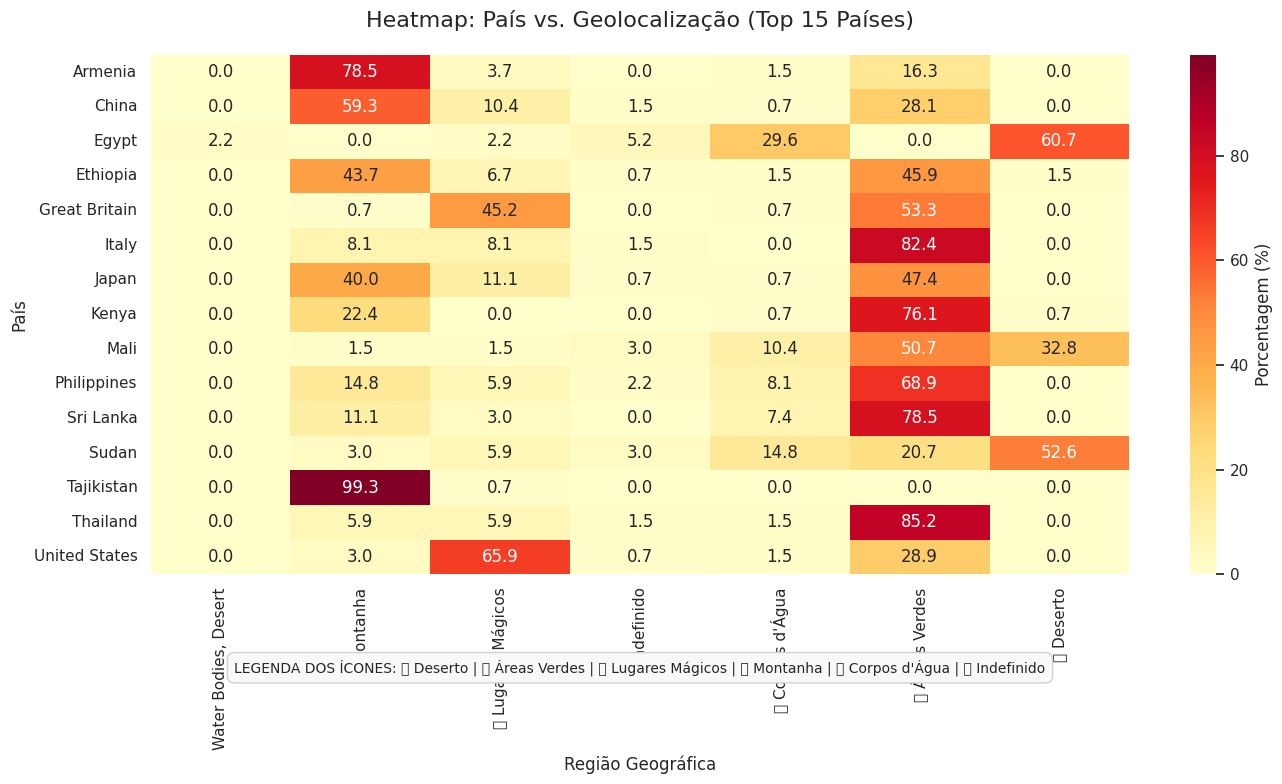

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

geo_df = df[df['country'].notna() & df['geolocation'].notna()].copy()

geo_counts = geo_df.groupby(['country', 'geolocation']).size().reset_index(name='count')
country_totals = geo_counts.groupby('country')['count'].transform('sum')
geo_counts['percentage'] = (geo_counts['count'] / country_totals) * 100

map_geo_pt = {
    'Desert': '🌵 Deserto',
    'Green Bodies': '🌳 Áreas Verdes',
    'Magical/Imaginary Places': '✨ Lugares Mágicos',
    'Mountain': '⛰️ Montanha',
    'Water Bodies': "🌊 Corpos d'Água",
    'None.': '❓ Indefinido'
}

geo_counts['geolocation_pt'] = geo_counts['geolocation'].map(map_geo_pt).fillna(geo_counts['geolocation'])

top_countries = geo_df['country'].value_counts().nlargest(15).index
geo_counts_filtered = geo_counts[geo_counts['country'].isin(top_countries)]

heatmap_geo_data = geo_counts_filtered.pivot_table(
    index='country',
    columns='geolocation_pt',
    values='percentage'
).fillna(0)

plt.figure(figsize=(14, 8))
sns.set_theme(style="white")

plt.rcParams['font.family'] = 'DejaVu Sans'

ax = sns.heatmap(
    heatmap_geo_data,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    cbar_kws={'label': 'Porcentagem (%)'}
)

plt.title('Heatmap: País vs. Geolocalização (Top 15 Países)', fontsize=16, pad=20)
plt.xlabel('Região Geográfica', fontsize=12)
plt.ylabel('País', fontsize=12)

legenda_itens = [f"{v}" for v in map_geo_pt.values()]
legenda_final = "LEGENDA DOS ÍCONES: " + " | ".join(legenda_itens)

plt.annotate(legenda_final, xy=(0.5, -0.18), xycoords='axes fraction',
             ha='center', va='center', fontsize=10,
             bbox=dict(boxstyle="round,pad=0.5", fc="#f9f9f9", ec="#d1d1d1", lw=1))

plt.tight_layout()
plt.show()

### 12. Nova Visualização: Heatmap de País vs. Classe Social
Esta análise verifica se existe uma correlação entre os países citados e o status socioeconômico atribuído aos personagens nas histórias.

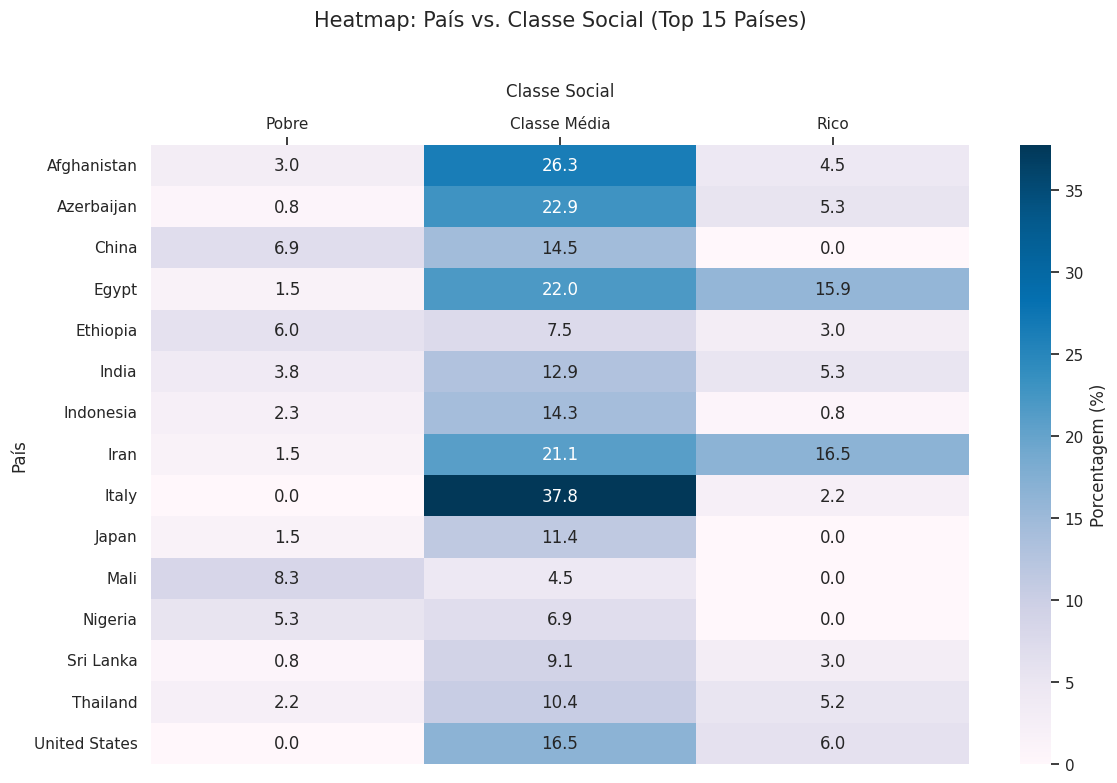

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

social_df = df[df['country'].notna() & df['social'].notna()].copy()

social_counts = social_df.groupby(['country', 'social']).size().reset_index(name='count')
country_social_totals = social_counts.groupby('country')['count'].transform('sum')
social_counts['percentage'] = (social_counts['count'] / country_social_totals) * 100

map_social_pt = {
    'Poor': 'Pobre',
    'Middle-class': 'Classe Média',
    'Wealthy': 'Rico',
    'None': 'Indefinido'
}
social_counts['social_pt'] = social_counts['social'].map(map_social_pt).fillna(social_counts['social'])

top_countries_social = social_df['country'].value_counts().nlargest(15).index
social_filtered = social_counts[social_counts['country'].isin(top_countries_social)]

heatmap_social_data = social_filtered.pivot_table(
    index='country',
    columns='social_pt',
    values='percentage'
).fillna(0)

ordem_social = ['Pobre', 'Classe Média', 'Rico', 'Indefinido']
heatmap_social_data = heatmap_social_data.reindex(columns=[c for c in ordem_social if c in heatmap_social_data.columns])

plt.figure(figsize=(12, 8))
ax = sns.heatmap(
    heatmap_social_data,
    annot=True,
    fmt=".1f",
    cmap="PuBu",
    cbar_kws={'label': 'Porcentagem (%)'}
)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.title('Heatmap: País vs. Classe Social (Top 15 Países)', fontsize=15, pad=40)
plt.xlabel('Classe Social', fontsize=12, labelpad=15)
plt.ylabel('País', fontsize=12)

plt.tight_layout()
plt.show()

### 13. Nova Visualização: Viés Lexical (Correlação de Pearson)
Seguindo a metodologia do artigo, vamos identificar quais palavras estão mais fortemente associadas a cada gênero do protagonista.

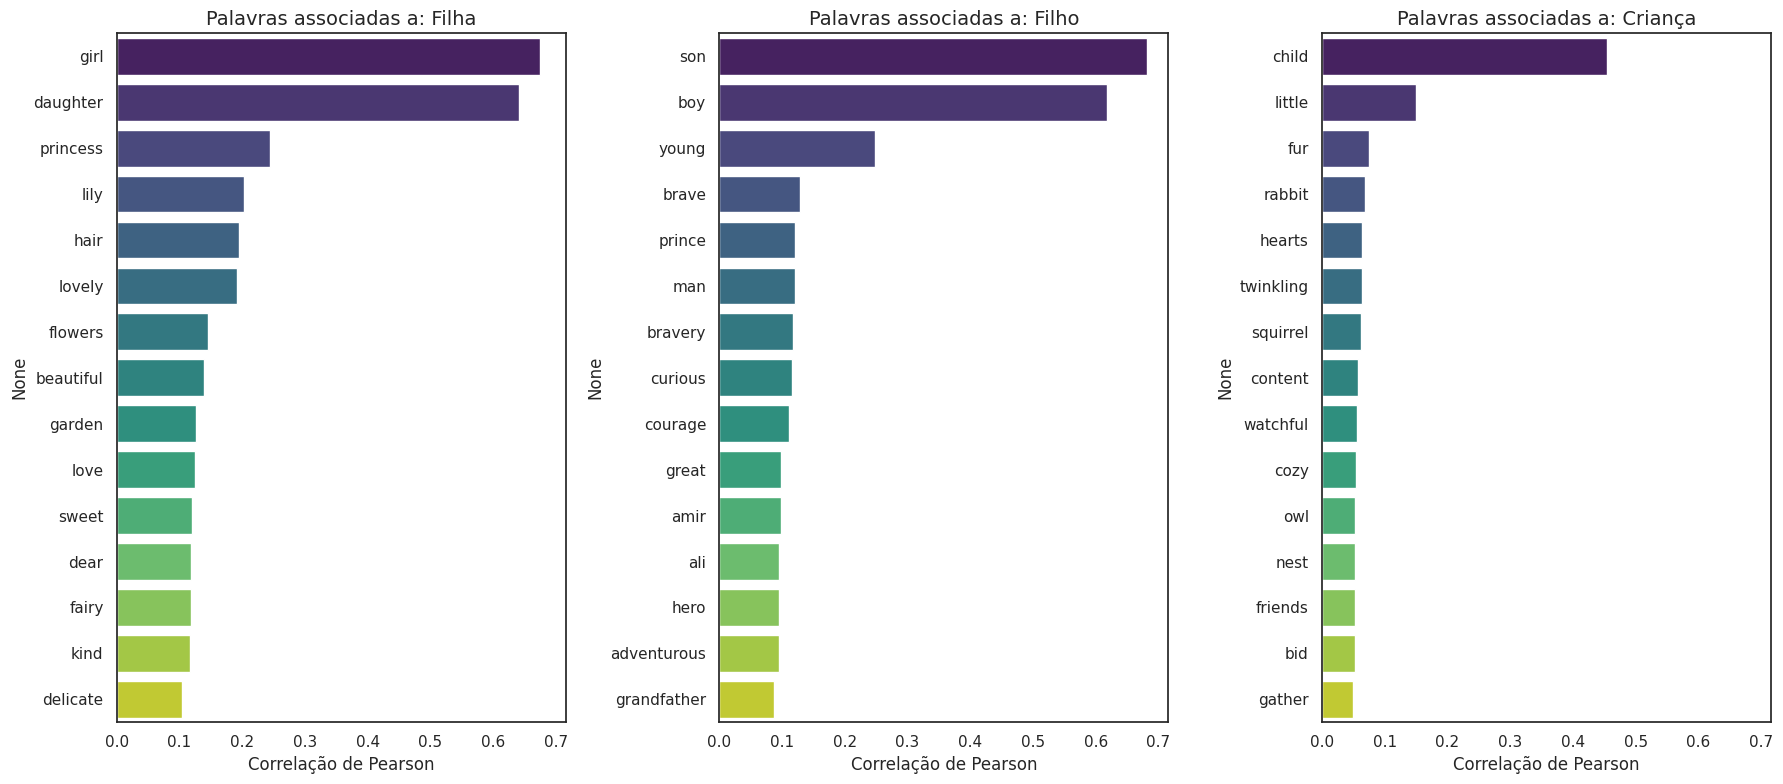

In [51]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import re

vectorizer = CountVectorizer(stop_words='english', max_features=1000, binary=True)
X = vectorizer.fit_transform(df['story'])
words_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

gender_dummies = pd.get_dummies(df['gender'])

correlations = {}
for gender in gender_dummies.columns:
    corrs = words_df.corrwith(gender_dummies[gender])
    correlations[gender] = corrs

corr_df = pd.DataFrame(correlations)

map_genero_pt = {'daughter': 'Filha', 'son': 'Filho', 'child': 'Criança'}

fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharex=True)

for i, gender in enumerate(['daughter', 'son', 'child']):
    top_words = corr_df[gender].sort_values(ascending=False).head(15)

    sns.barplot(
        x=top_words.values,
        y=top_words.index,
        ax=axes[i],
        palette='viridis'
    )

    axes[i].set_title(f'Palavras associadas a: {map_genero_pt[gender]}', fontsize=14)
    axes[i].set_xlabel('Correlação de Pearson')

plt.tight_layout()
plt.show()

### 14. Nova Visualização: Viés Lexical com TF-IDF
Nesta versão, utilizamos o `TfidfVectorizer` para extrair as palavras mais características, ponderando sua frequência nas histórias contra a frequência em todo o dataset.

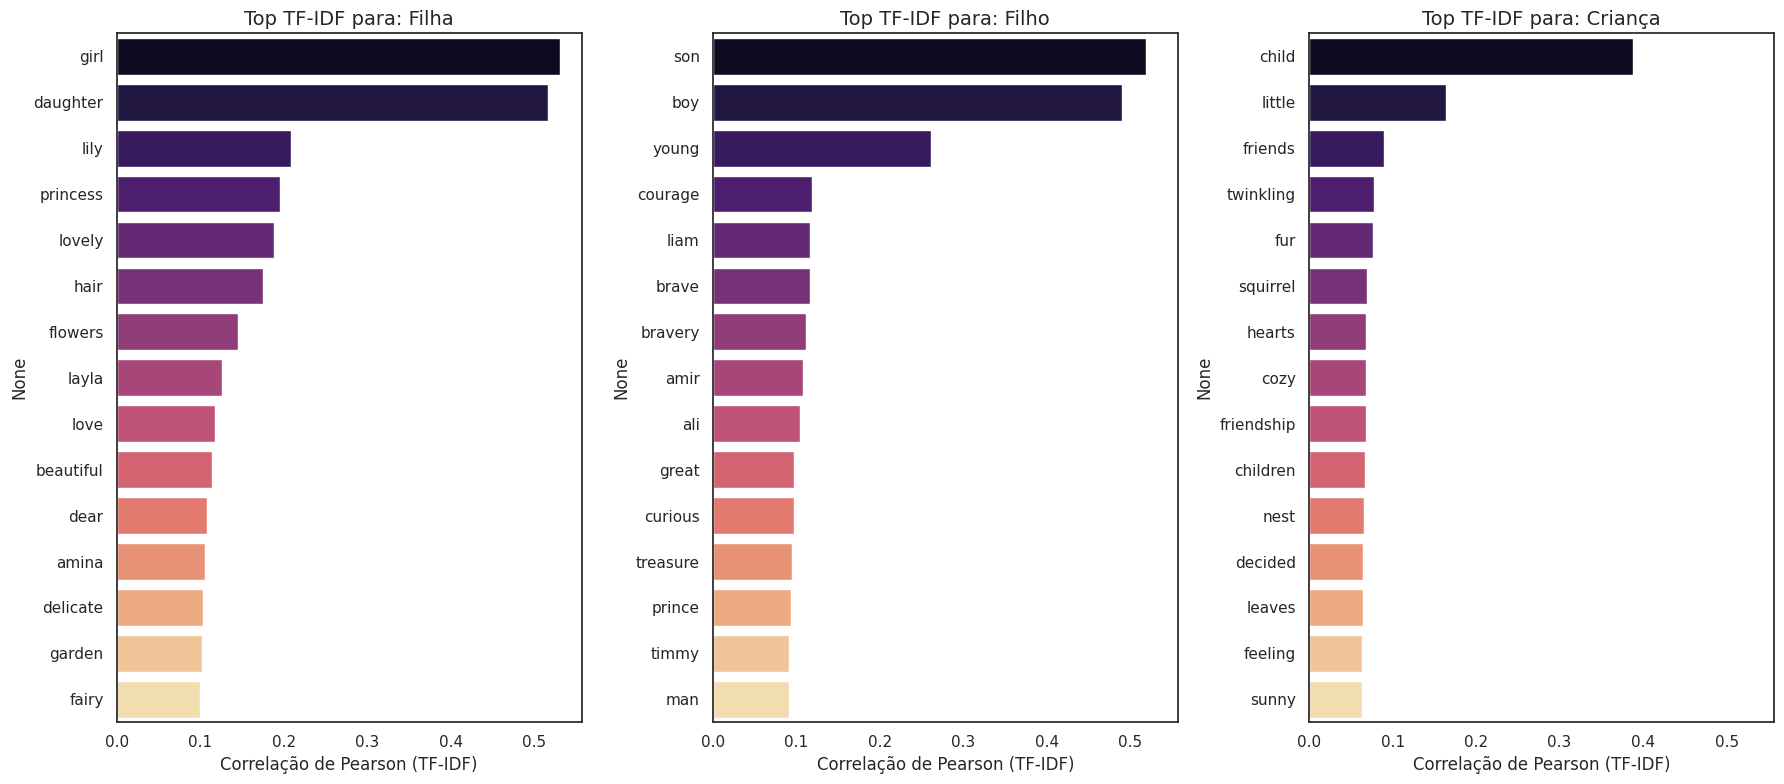

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X_tfidf = tfidf_vectorizer.fit_transform(df['story'])
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

correlations_tfidf = {}
for gender in gender_dummies.columns:
    corrs = tfidf_df.corrwith(gender_dummies[gender])
    correlations_tfidf[gender] = corrs

corr_tfidf_df = pd.DataFrame(correlations_tfidf)

fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharex=True)

for i, gender in enumerate(['daughter', 'son', 'child']):
    top_words_tfidf = corr_tfidf_df[gender].sort_values(ascending=False).head(15)

    sns.barplot(
        x=top_words_tfidf.values,
        y=top_words_tfidf.index,
        ax=axes[i],
        palette='magma'
    )

    axes[i].set_title(f'Top TF-IDF para: {map_genero_pt[gender]}', fontsize=14)
    axes[i].set_xlabel('Correlação de Pearson (TF-IDF)')

plt.tight_layout()
plt.show()

## 15. Desafios encontrados
- **Tratamento de Dados**: O dataset utiliza ponto e vírgula como separador e contém caracteres especiais que causaram erros de parsing inicial no Pandas.
- **Estrutura de Listas**: Atributos como `protagonist_attrs` estão armazenados como strings de listas, exigindo o uso de `ast.literal_eval` para processamento.
- **Dados Faltantes**: Algumas colunas culturais (religião e etnia) possuem muitos valores nulos, o que é esperado dado que nem toda história especifica esses detalhes.

## 16. Conclusão
A reprodução parcial do artigo *Biased Tales* permitiu observar padrões na geração de histórias por modelos de linguagem. Embora os modelos tendam a atribuir traços positivos como 'kind' e 'curious' a ambos os gêneros, ainda existem diferenças sutis na escolha de adjetivos que podem refletir vieses de treinamento. Esta análise serve como base para estudos mais profundos sobre segurança e ética em modelos generativos.